In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import sklearn

In [ ]:
df = pd.read_csv("train.csv")
display(df.head())
df.info(max_cols=None)
df.describe()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
count,10487.000000,10487.000000,9986.000000,9986.000000,10487.000000,10487.000000,9986.000000,10487.000000,10487.000000,10487.000000,...,10487.000000,10487.000000,10487.000000,10487.000000,9.986000e+03,9986.000000,10487.000000,10487.000000,10487.000000,1.048700e+04
mean,39.850386,131587.872127,678.082716,29874.218306,53.439878,1.568323,546.458642,0.284397,3.033565,0.979498,...,10838.934141,0.784428,4.949271,17.628302,1.542381e+05,0.200392,0.200112,1075.622426,0.517577,-2.569878e+04
std,11.614132,115791.941909,175.192486,27705.509722,24.493562,1.418684,501.981888,0.159240,1.740186,0.990927,...,9385.924858,0.123039,2.201100,11.337248,4.622229e+05,0.094388,0.096458,1344.053181,0.894637,1.431675e+06
min,18.000000,15000.000000,300.000000,1063.000000,12.000000,0.000000,13.000000,0.003674,0.000000,0.000000,...,1250.000000,0.259301,0.000000,0.000000,1.004000e+03,0.052494,0.046445,30.008506,0.006064,-9.999999e+06
25%,32.000000,20959.500000,550.000000,12658.000000,36.000000,0.000000,233.250000,0.158929,2.000000,0.000000,...,1683.541667,0.708475,3.000000,9.000000,7.252500e+03,0.119908,0.119548,375.872620,0.066734,3.256475e+01
50%,40.000000,89015.000000,722.500000,21828.500000,48.000000,1.000000,398.000000,0.262229,3.000000,1.000000,...,7371.250000,0.803692,5.000000,17.000000,2.742950e+04,0.182023,0.180710,684.878529,0.178193,4.411876e+01
75%,48.000000,257025.000000,850.000000,37158.000000,60.000000,3.000000,685.000000,0.391683,4.000000,2.000000,...,21232.583333,0.879312,6.000000,26.000000,1.241758e+05,0.264709,0.264880,1279.930203,0.637457,6.535690e+01
max,80.000000,748508.000000,850.000000,418997.000000,120.000000,6.000000,10879.000000,0.914635,12.000000,6.000000,...,25000.000000,0.996573,17.000000,57.000000,1.126117e+07,0.722497,0.833647,29634.807816,24.383046,1.000000e+07


# Нормировка

In [7]:
def zscore_fit(X_nums):
    mean = X_nums.mean(axis=0)
    std = X_nums.std(axis=0)
    new_std = std.copy()
    new_std[new_std == 0] = 1.0
    return mean, new_std

def zscore_transform(X, mean, std):
    return (X - mean) / std

def minmax_fit(X_nums):
    min_vals = X_nums.min(axis=0)
    max_vals = X_nums.max(axis=0)
    return min_vals, max_vals

def minmax_transform(X, min_vals, max_vals):
    denoms = max_vals - min_vals
    denoms[denoms == 0] = 1.0
    return (X - min_vals) / denoms

# Подготовка данных:
удаление и заполнение потерянных данных, one-hot encoding категориальных признаков, нормировка

In [140]:
def make_train(path):
    df = pd.read_csv(path)

    df = df.dropna(how='all')
    df = df[(df['RiskScore'] >= 0) & (df['RiskScore'] <= 100)]

    df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
    df['AppYear'] = df['ApplicationDate'].dt.year
    df['AppMonth'] = df['ApplicationDate'].dt.month
    df['AppDay'] = df['ApplicationDate'].dt.day
    df['AppWeekday'] = df['ApplicationDate'].dt.weekday
    df = df.drop('ApplicationDate', axis=1)

    num_medians = df.median(numeric_only=True)
    cat_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']

    num_cols = set(df.columns.tolist()) - set(cat_cols)
    num_cols.remove('RiskScore')
    num_cols = list(num_cols)

    cat_modes = df[cat_cols].mode().iloc[0]

    df[num_cols] = df[num_cols].fillna(num_medians)
    df[cat_cols] = df[cat_cols].fillna(cat_modes)

    df = pd.get_dummies(df, columns=['MaritalStatus', 
                                 'HomeOwnershipStatus',
                                 'LoanPurpose',
                                 'EmploymentStatus',
                                 'EducationLevel'],
                    drop_first=True)
    
    
    
    return df, num_medians, cat_modes, num_cols

def make_test(path, num_medians, cat_modes, num_cols):
    df = pd.read_csv(path)
    cat_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']
    
    df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
    df['AppYear'] = df['ApplicationDate'].dt.year
    df['AppMonth'] = df['ApplicationDate'].dt.month
    df['AppDay'] = df['ApplicationDate'].dt.day
    df['AppWeekday'] = df['ApplicationDate'].dt.weekday
    df = df.drop('ApplicationDate', axis=1)

    df[num_cols] = df[num_cols].fillna(num_medians)
    df[cat_cols] = df[cat_cols].fillna(cat_modes)

    df = pd.get_dummies(df, columns=['MaritalStatus', 
                                 'HomeOwnershipStatus',
                                 'LoanPurpose',
                                 'EmploymentStatus',
                                 'EducationLevel'],
                    drop_first=True)
    return df

# 1. Базовая подготовка train/test (без нормализации)
train, num_medians, cat_modes, to_norm = make_train('train.csv')
test = make_test('test.csv', num_medians, cat_modes, to_norm)

# 2. Помечаем и объединяем
train['is_train'] = 1
test['is_train'] = 0

combined = pd.concat([train, test], ignore_index=True)

# 3. Генерируем дополнительные признаки
combined_enh = generate_enhanced_features(combined)
combined_enh.describe()

# combined_enh = combined

# 4. Разделяем обратно
train_enh = combined_enh[combined_enh['is_train'] == 1].drop(['is_train', 'ID'], axis=1)
test_enh  = combined_enh[combined_enh['is_train'] == 0].drop(['is_train', 'RiskScore'], axis=1)

# 5. Нормализация только по train, только по числовым признакам (кроме RiskScore, ID)
num_cols_final = [
    c for c in train_enh.columns
    if c not in ['RiskScore', 'ID'] and np.issubdtype(train_enh[c].dtype, np.number)
]

z_mean, z_std = zscore_fit(train_enh[num_cols_final])

train_enh[num_cols_final] = zscore_transform(train_enh[num_cols_final], z_mean, z_std)
test_enh[num_cols_final]  = zscore_transform(test_enh[num_cols_final],  z_mean, z_std)

train_enh.info(max_cols=None)
test_enh.info(max_cols=None)

train_enh.describe()
test_enh.describe()

display(train_enh.head())
display(test_enh.head())

train = train_enh
test = test_enh

print(num_cols_final)

#train.describe()
# test.describe()

multicolliner_list = ['Experience', 'TotalAssets', 'BaseInterestRate', 'AnnualIncome']

# train = train.drop(multicolliner_list, axis=1)
# test = test.drop(multicolliner_list, axis=1)


<class 'pandas.core.frame.DataFrame'>
Index: 10272 entries, 0 to 10271
Data columns (total 66 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             10272 non-null  float64
 1   AnnualIncome                    10272 non-null  float64
 2   CreditScore                     10272 non-null  float64
 3   LoanAmount                      10272 non-null  float64
 4   LoanDuration                    10272 non-null  float64
 5   NumberOfDependents              10272 non-null  float64
 6   MonthlyDebtPayments             10272 non-null  float64
 7   CreditCardUtilizationRate       10272 non-null  float64
 8   NumberOfOpenCreditLines         10272 non-null  float64
 9   NumberOfCreditInquiries         10272 non-null  float64
 10  DebtToIncomeRatio               10272 non-null  float64
 11  BankruptcyHistory               10272 non-null  float64
 12  PreviousLoanDefaults            10272

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,log_TotalAssets,log_TotalLiabilities,log_MonthlyIncome,log_NetWorth,CreditScore_sq,InterestRate_sq,TotalDebtToIncomeRatio_sq,CreditScore_x_InterestRate,TDTI_x_InterestRate,CreditScore_x_TDTI
0,-1.108397,-0.558623,-0.764082,-0.450445,0.268118,-0.400553,1.130130,-0.831655,-0.591900,0.022254,...,-0.174414,-0.254823,-0.100490,0.071829,-0.894871,0.292066,-0.103782,0.461433,-0.190176,-0.273725
1,1.304469,0.350642,0.991648,-0.493824,-0.710597,-0.400553,-0.668084,-0.682942,-0.016742,-0.989233,...,0.269839,0.718332,0.713883,-0.077716,1.084502,-0.860077,-0.112184,-1.178066,-0.344551,-0.546444
2,0.959774,1.454464,0.991648,0.326913,-0.710597,-1.105933,0.013366,1.003914,-0.016742,-0.989233,...,1.116868,-0.304806,1.191956,1.257137,1.084502,-0.761956,-0.111901,-0.650761,-0.336196,-0.502173
3,-1.280745,-0.836156,0.974149,-0.380745,-0.221240,-1.105933,-0.786066,-0.602906,2.283892,-0.989233,...,-1.157411,-1.159580,-0.664913,-0.692191,1.060571,-0.774595,-0.107141,-0.722267,-0.297316,-0.196007
4,1.304469,1.454464,0.991648,0.032858,-0.221240,0.304827,0.045913,-0.069840,-0.016742,0.022254,...,-0.471698,1.841668,1.191956,-1.102515,1.084502,-0.875992,-0.112161,-1.275986,-0.344595,-0.542143


,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,log_TotalAssets,log_TotalLiabilities,log_MonthlyIncome,log_NetWorth,CreditScore_sq,InterestRate_sq,TotalDebtToIncomeRatio_sq,CreditScore_x_InterestRate,TDTI_x_InterestRate,CreditScore_x_TDTI
10272,0.787427,0.652367,0.991648,-0.554554,0.268118,-1.105933,-0.332444,-1.301249,-0.591900,-0.989233,...,-1.774136,0.099856,0.872967,-0.611244,1.084502,-0.711578,-0.112278,-0.416209,-0.343680,-0.566450
10273,-1.022223,-0.577410,-0.034958,1.321494,-0.221240,0.304827,-0.613161,-1.320993,0.558417,1.033742,...,1.176946,-0.123531,-0.128978,1.298062,-0.176283,0.390431,-0.090872,1.507795,-0.085356,0.077243
10274,0.098036,1.454464,0.513343,-0.468054,0.268118,-0.400553,-0.143266,0.294410,1.133575,-0.989233,...,-1.154896,-0.849139,1.191956,-0.851743,0.460859,-0.538827,-0.112324,-0.077393,-0.342991,-0.584773
10275,0.873600,1.454464,0.991648,0.705593,-0.710597,-1.105933,0.056084,1.631771,-0.591900,0.022254,...,-0.673455,0.963426,1.191956,-0.743142,1.084502,-0.833439,-0.111686,-1.023236,-0.335847,-0.476023
10276,-0.419007,1.454464,-0.046624,0.822457,0.268118,3.126346,-0.881672,0.950581,-1.742217,-0.989233,...,1.414656,-1.358273,1.191956,1.514110,-0.188937,0.150131,-0.112027,1.065846,-0.320768,-0.546885


['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'AppYear', 'AppMonth', 'AppDay', 'AppWeekday', 'DisposableIncome', 'log_DisposableIncome', 'log_AnnualIncome', 'log_LoanAmount', 'log_MonthlyDebtPayments', 'log_SavingsAccountBalance', 'log_CheckingAccountBalance', 'log_TotalAssets', 'log_TotalLiabilities', 'log_MonthlyIncome', 'log_NetWorth', 'CreditScore_sq', 'InterestRate_sq', 'TotalDebtToIncomeRatio_sq', 'CreditScore_x_InterestRate', 'TDTI_x_InterestRate', 'CreditScore_x_TDTI']


In [134]:
def generate_enhanced_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Дополнительный признак: свободный доход
    if 'MonthlyIncome' in df.columns and 'MonthlyDebtPayments' in df.columns:
        df['DisposableIncome'] = df['MonthlyIncome'] - df['MonthlyDebtPayments']

        # логарифм свободного дохода с сдвигом, чтобы не было лог(<=0)
        min_val = df['DisposableIncome'].min()
        offset = 1.0 - min_val if min_val <= 0 else 0.0
        df['log_DisposableIncome'] = np.log(df['DisposableIncome'] + offset)

    # 2. Логарифмы "денежных" признаков (если есть)
    skewed_features = [
        'AnnualIncome', 'LoanAmount', 'MonthlyDebtPayments',
        'SavingsAccountBalance', 'CheckingAccountBalance',
        'TotalAssets', 'TotalLiabilities', 'MonthlyIncome',
        'NetWorth'
    ]
    for col in skewed_features:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    # 3. Квадраты и пары важнейших признаков
    quad_features = [
        'CreditScore',
        'InterestRate',
        'TotalDebtToIncomeRatio'
    ]
    for col in quad_features:
        if col in df.columns:
            df[f'{col}_sq'] = df[col] ** 2

    # 4. Простые взаимодействия (произведения)
    if 'CreditScore' in df.columns and 'InterestRate' in df.columns:
        df['CreditScore_x_InterestRate'] = df['CreditScore'] * df['InterestRate']

    if 'TotalDebtToIncomeRatio' in df.columns and 'InterestRate' in df.columns:
        df['TDTI_x_InterestRate'] = df['TotalDebtToIncomeRatio'] * df['InterestRate']

    if 'CreditScore' in df.columns and 'TotalDebtToIncomeRatio' in df.columns:
        df['CreditScore_x_TDTI'] = df['CreditScore'] * df['TotalDebtToIncomeRatio']

    return df


# EDA:
общий heatmap, отдельный для признаков 

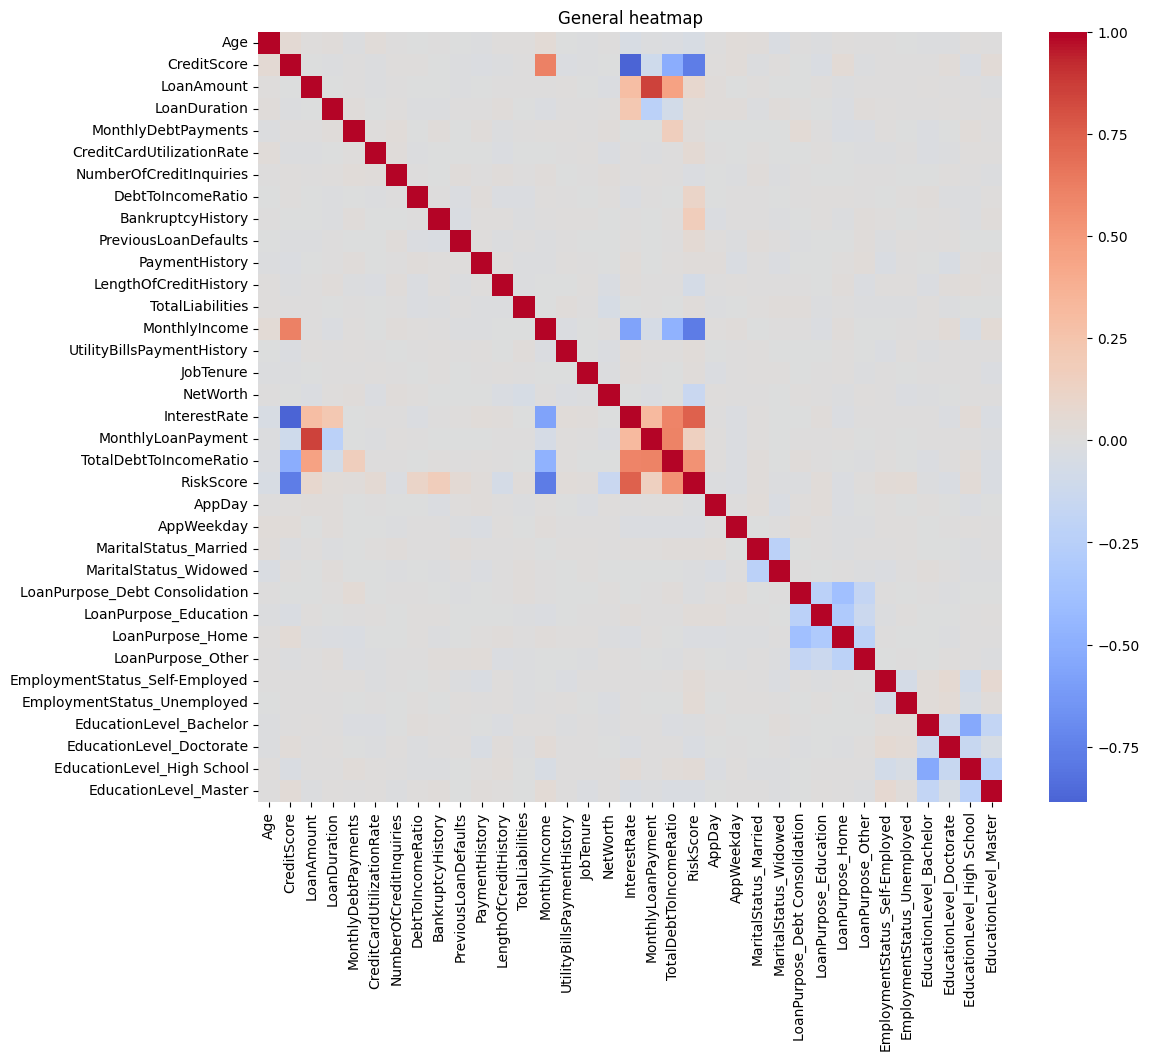

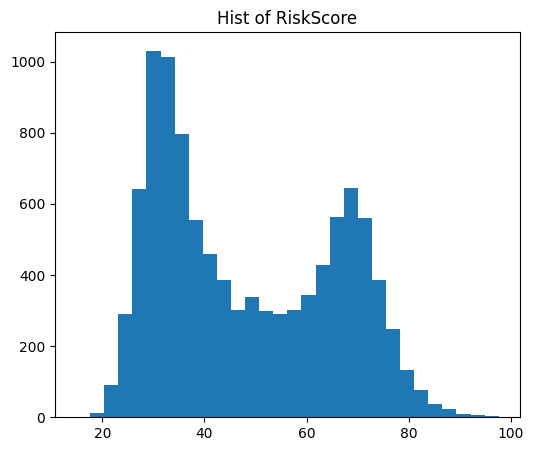

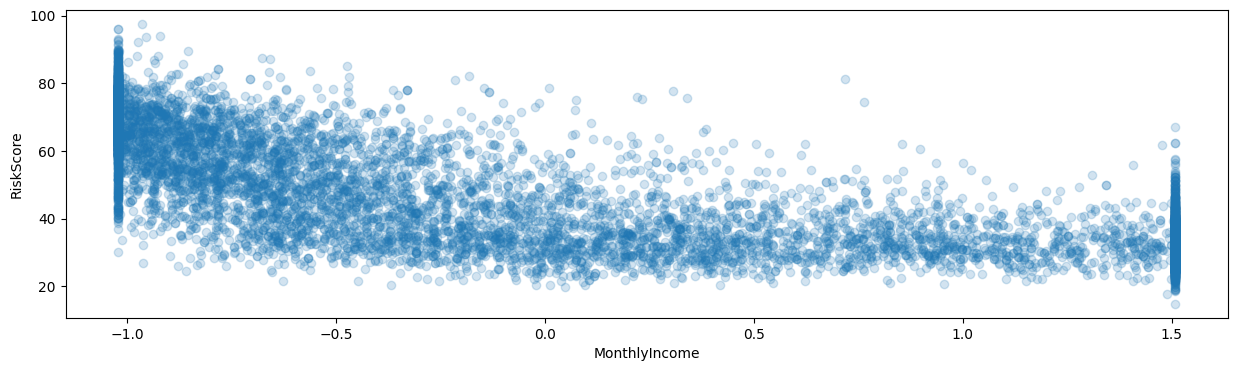

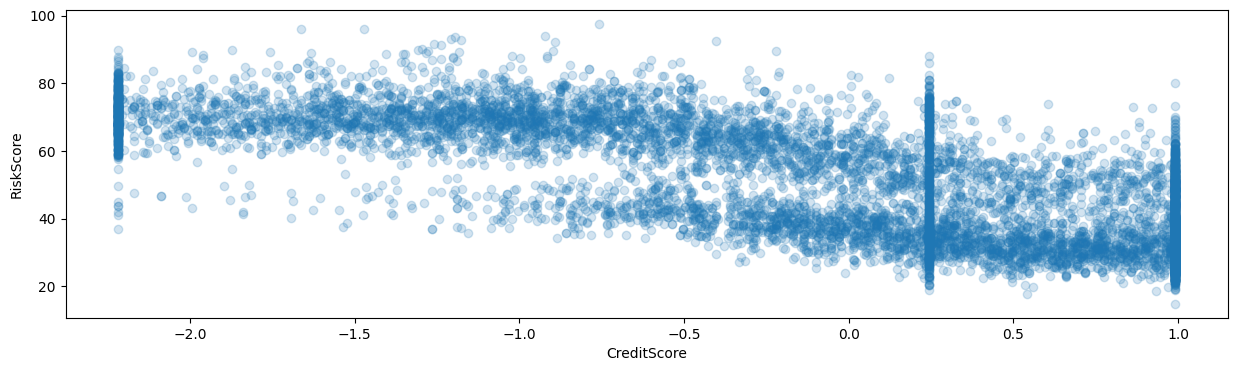

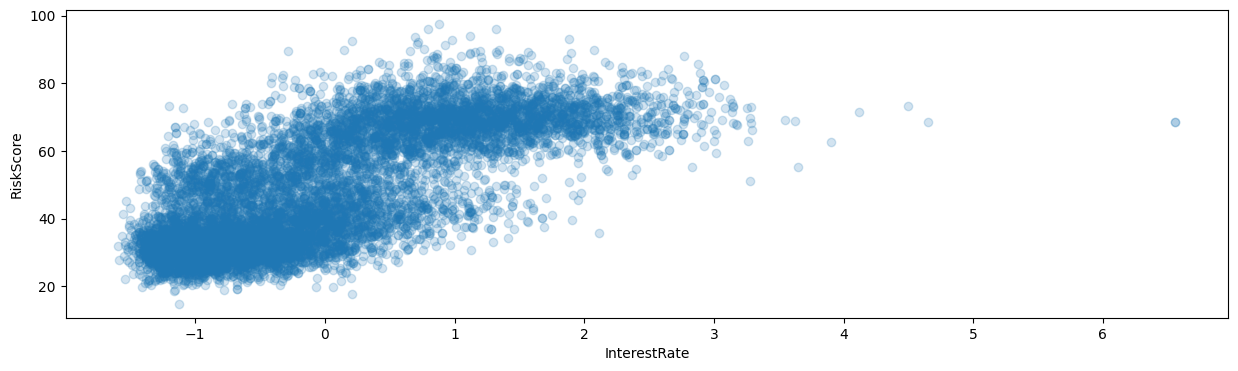

In [89]:
corr = train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('General heatmap')
plt.show()

# plt.figure(figsize=(12, 10))
# #corr2 = train[['AnnualIncome', 'CreditScore','MonthlyIncome', 'BaseInterestRate', 'InterestRate', 'TotalDebtToIncomeRatio', 'MonthlyLoanPayment', 'LoanAmount', 'LoanDuration',]].corr()
# corr2 = train[['CreditScore','MonthlyIncome', 'InterestRate', 'TotalDebtToIncomeRatio', 'MonthlyLoanPayment', 'LoanAmount', 'LoanDuration',]].corr()
# sns.heatmap(corr2, cmap='coolwarm', center=0)
# plt.title('Colinear heatmap')
# plt.show()

plt.figure(figsize=(6, 5))
plt.hist(train['RiskScore'], bins=30)
plt.title('Hist of RiskScore')
plt.show()


plt.figure(figsize=(15, 4))
plt.scatter(train['MonthlyIncome'], train['RiskScore'], alpha=0.2)
plt.xlabel("MonthlyIncome")
plt.ylabel("RiskScore")
plt.show()

plt.figure(figsize=(15, 4))
plt.scatter(train['CreditScore'], train['RiskScore'], alpha=0.2)
plt.xlabel("CreditScore")
plt.ylabel("RiskScore")
plt.show()

plt.figure(figsize=(15, 4))
plt.scatter(train['InterestRate'], train['RiskScore'], alpha=0.2)
plt.xlabel("InterestRate")
plt.ylabel("RiskScore")
plt.show()

# plt.figure(figsize=(8, 8))
# plt.scatter(train['Age'], train['Experience'], alpha=0.2)
# plt.xlabel("Age")
# plt.ylabel("Experience")
# plt.show()

# plt.figure(figsize=(8, 8))
# plt.scatter(train['NetWorth'], train['TotalAssets'], alpha=0.2)
# plt.xlabel("NetWorth")
# plt.ylabel("TotalAssets")
# plt.show()


# есть сильная корреляция между Age и Experience, а также между NetWorth и TotalAssets

# есть 2 множества сильно скоррелированных признаков
# А = (AnnualIncome, CreditScore и MonthlyIncome)
# Б =(BaseInterestRate, InterestRate)
# группа Б имеет также некоторую корреляцию с MonthlyLoanPayment и TotalDebtToIncomeRatio
# группа A и Б имеют между собой отрицательную корреляцию

# отрицательная корреляция присутсвует между группами one-hot признаков, но это и логично

# можно убрать Experience, TotalAssets, BaseInterestRate, AnnualIncome



# ЛИНЕЙНАЯ РЕГРЕССИЯ

In [104]:
class MyLinearRegression:
    def __init__(self, method='analytic', lr=0.01, n_iters=1000, reg_type=None, reg_lambda=0.0):
        self.method = method
        self.lr = lr
        self.n_iters = n_iters
        self.reg_type = reg_type
        self.reg_lambda = reg_lambda
        self.weights_ = None

    def _add_bias(self, X: pd.DataFrame):
        X = np.asarray(X, dtype=float)
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X, y):
        X = self._add_bias(X)
        y = np.array(y, dtype=float)
        if (self.method == 'analytic'):
            if self.reg_type == 'l2' and self.reg_lambda > 0:
                N, D = X.shape
                XtX = X.T @ X
                reg_matrix = self.reg_lambda * np.eye(D)
                reg_matrix[0, 0] = 0.0
                self.weights_ = np.linalg.pinv(XtX + reg_matrix) @ (X.T @ y)
            else:
                self.weights_ = np.linalg.pinv(X) @ y
        elif self.method == 'gd':
            N, S = X.shape
            self.weights_ = np.zeros(S)
            for _ in range(self.n_iters):
                err = X @ self.weights_ - y
                grad =  2 / N * (X.T @ err)

                if self.reg_type == 'l2' and self.reg_lambda > 0:
                    grad[1:] += 2 * self.reg_lambda * self.weights_[1:]
                if self.reg_type == 'l1' and self.reg_lambda > 0:
                    grad[1:] += self.reg_lambda * np.sign(self.weights_[1:])
                
                self.weights_ -= self.lr * grad
        elif self.method == 'sgd':
            N, S = X.shape
            self.weights_ = np.zeros(S)
            for epoch in range(self.n_iters):
                for ind in np.random.permutation(N):
                    err = X[ind] @ self.weights_ - y[ind]
                    grad = 2 * X[ind] * err

                    if self.reg_type == 'l2' and self.reg_lambda > 0:
                        grad[1:] += 2 * self.reg_lambda * self.weights_[1:]
                    if self.reg_type == 'l1' and self.reg_lambda > 0:
                        grad[1:] += self.reg_lambda * np.sign(self.weights_[1:])

                    self.weights_ -= self.lr * grad
        

    def predict(self, X):
        X = self._add_bias(X)
        return X @ self.weights_
    
    def get_params(self, deep=True):
        return {
            "method": self.method,
            "lr": self.lr,
            "n_iters": self.n_iters,
            "reg_type": self.reg_type,
            "reg_lambda": self.reg_lambda,
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = train.drop('RiskScore', axis=1).values
y = train['RiskScore'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "my_analytic": MyLinearRegression(method='analytic'),
    "my_gd": MyLinearRegression(method='gd', lr=0.01, n_iters=1000),
    "my_sgd": MyLinearRegression(method='sgd', lr=0.001, n_iters=20),
    "sklearn": LinearRegression()
}

results = []

for name, model in models.items():
    # fit
    if name == "sklearn":
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)

    # predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # mse
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    results.append({
        "model": name,
        "train_mse": train_mse,
        "val_mse": val_mse
    })

results_df = pd.DataFrame(results).set_index("model")
display(results_df)

,train_mse,val_mse
model,,
my_analytic,52.072263,53.779401
my_gd,58.284089,58.373910
my_sgd,53.986439,55.448171
sklearn,52.072263,53.779401


# Метрики

In [92]:
def my_mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def my_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def my_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1 - ss_res / ss_tot


def my_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (y_true))) * 100


In [93]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

model1 =  MyLinearRegression(method='analytic')
X = train.drop('RiskScore', axis=1).values
y = train['RiskScore'].values
model1.fit(X, y)

y_pred = model1.predict(X)

results = (
    {
        "metric" : "MSE",
        "my_res" : my_mse(y, y_pred),
        "sklearn_res" : mean_squared_error(y, y_pred)
    },
    {
        "metric" : "MAE",
        "my_res" : my_mae(y, y_pred),
        "sklearn_res" : mean_absolute_error(y, y_pred)
    },
    {
        "metric" : "R2",
        "my_res" : my_r2(y, y_pred),
        "sklearn_res" : r2_score(y, y_pred)
    },
    {
        "metric" : "MAPE",
        "my_res" : my_mape(y, y_pred),
        "sklearn_res" : mean_absolute_percentage_error(y, y_pred) * 100
    }
)

results_df = pd.DataFrame(results).set_index("metric")
display(results_df)


,my_res,sklearn_res
metric,,
MSE,52.406523,52.406523
MAE,5.805914,5.805914
R2,0.823689,0.823689
MAPE,13.630113,13.630113


# Кроссвалидация

In [94]:
def my_k_fold_cv(model_cls, X, y, k=5, shuffle=True, random_state=42, **model_params):
    X = np.asarray(X)
    y = np.asarray(y)

    N = len(X)

    idx = np.arange(N)
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(idx)

    fold_sizes = np.full(k, N // k)
    fold_sizes[:N % k] += 1

    current = 0
    mse_list = []

    for fold_size in fold_sizes:
        start, end = current, current + fold_size
        val_idx = idx[start:end]
        train_idx = np.concatenate([idx[:start], idx[end:]])

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = model_cls(**model_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mse = np.mean((y_val - y_pred) ** 2)
        mse_list.append(mse)

        current = end

    return np.mean(mse_list), mse_list

def my_loo_cv(model_cls, X, y, **model_params):
    X = np.asarray(X)
    y = np.asarray(y)
    N = len(X)

    mse_list = []

    for i in range(N):
        X_val = X[i:i+1]
        y_val = y[i:i+1]

        X_train = np.concatenate([X[:i], X[i+1:]])
        y_train =  np.concatenate([y[:i], y[i+1:]])

        model = model_cls(**model_params)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        mse = (y_pred - y_val) ** 2
        mse_list.append(mse.item())

    return np.mean(mse_list), mse_list

In [141]:
X = train.drop('RiskScore', axis=1).values
y = train['RiskScore'].values

mean_mse_k_fold1, folds = my_k_fold_cv(MyLinearRegression, X, y, k=5, method='analytic')
# mean_mse_loo, folds = my_loo_cv(MyLinearRegression, X[:100], y[:100], method='analytic')

mean_mse_k_fold2, folds = my_k_fold_cv(MyLinearRegression, X, y, k=5, method='gd', lr=0.01, n_iters=1000)
mean_mse_k_fold3, folds = my_k_fold_cv(MyLinearRegression, X, y, k=5, method='sgd', lr=0.001, n_iters=20)

# print("Mean Leave-One-Out CV MSE:", mean_mse_loo)

results = (
    {
        "method" : "analitic",
        "k_fold_res" : mean_mse_k_fold1,
    },
    {
        "method" : "gd",
        "k_fold_res" : mean_mse_k_fold2,
    },
    {
        "method" : "sgd",
        "k_fold_res" : mean_mse_k_fold3,
    }
)

results_df = pd.DataFrame(results).set_index("method")
display(results_df)

,k_fold_res
method,
analitic,5.208598e+01
gd,4.446404e+01
sgd,1.878863e+25


# Submission

In [142]:
X_train = train.drop('RiskScore', axis=1).values
y_train = train['RiskScore'].values

X_test = test.drop('ID', axis=1).values
test_id = test['ID'].values

model = MyLinearRegression(method='analytic', reg_type='l2', reg_lambda=0.1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

submission = pd.DataFrame({
    "ID": test_id,
    "RiskScore": y_pred
})

submission.to_csv("submission.csv", index=False)
